# METAR comparison to reanalysis products 

This notebook is set up to compare METAR to reanalysis products. The comparison is done with time series for a particular location first, then map-based comparisons for time periods. 

This notebook is set up to compare METAR with [AORC](https://registry.opendata.aws/noaa-nws-aorc/) data, a reanalysis product produced by NOAA for the continental U.S. and Alaska from 1979-2023. 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import s3fs

from datetime import datetime, timedelta

import metpy.calc as mpcalc
from metpy.units import units

import geopandas as gpd
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import duckdb

### Time series comparison 

#### Get the METAR data 
Data is hosted on [Dynamical](https://dynamical.org/). Choose a location and a time range. 

Our METAR Parquet file contains some weird column names, so we define some more descriptive names here. The full documentation for column names can be found [here](https://unidata.github.io/gempak/man/parm/apxA.html). 

In [2]:
col_refs = {
    'tmpc': 'Temperature (degC)', 
    'relh': 'Relative Humidity (%)',
    'drct': 'Wind Direction (deg)',
    'sknt': 'Wind Speed (knots)',
}

In [3]:
def valid_date(date): 
    '''
    Helper function to check that the date range is valid for METAR and AORC.
    '''
    assert isinstance(date, datetime)
    assert date >= datetime(1979, 1, 1, 0), 'Date cannot be earlier than 1979' 
    assert date < datetime(2024, 1, 1, 0), 'Date cannot be more recent than 2023' 
    return date

In [4]:
# define target! 
target = (39.8328, -104.6575)
target_code = 'DEN'
# TODO add "find_closest_metar" functionality, bounding box search, etc. 

time_start = valid_date(datetime(2021, 1, 1, 0))
time_end = valid_date(datetime(2021, 5, 31, 23))

target_vars = ['tmpc', 'relh', 'drct', 'sknt']

We'll need different files if the time range spans multiple years. 

In [5]:
metar_base = "https://data.source.coop/dynamical/asos-parquet"
metar_urls = [f"{metar_base}/year={y}/data.parquet" for y in range(time_start.year, time_end.year + 1)]
metar_urls

['https://data.source.coop/dynamical/asos-parquet/year=2021/data.parquet']

In [6]:
df = duckdb.execute(f"""
    SELECT valid, longitude, latitude, station, name, country, {', '.join(target_vars)}
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = $2 and 
          valid between $3 and $4
    ORDER BY valid
""", [metar_urls, target_code, time_start, time_end]).fetchdf()

In [7]:
# df = duckdb.execute(f"""
#     SELECT *
#     FROM read_parquet($1, hive_partitioning=true)
#     WHERE station = $2
#     ORDER BY valid
# """, [metar_urls[1], target_code]).fetchdf()

In [8]:
df.columns

Index(['valid', 'longitude', 'latitude', 'station', 'name', 'country', 'tmpc',
       'relh', 'drct', 'sknt'],
      dtype='object')

In [9]:
gdf_metar = gpd.GeoDataFrame(
                df, 
                geometry=gpd.points_from_xy(df.longitude,
                                            df.latitude)
)
gdf_metar

,valid,longitude,latitude,station,name,country,tmpc,relh,drct,sknt,geometry
0,2021-01-01 00:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,0.00,60.55,340.0,5.0,POINT (-104.6575 39.8328)
1,2021-01-01 01:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,-0.61,66.34,340.0,5.0,POINT (-104.6575 39.8328)
2,2021-01-01 02:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,0.00,55.82,0.0,0.0,POINT (-104.6575 39.8328)
3,2021-01-01 03:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,0.00,60.55,0.0,0.0,POINT (-104.6575 39.8328)
4,2021-01-01 04:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,0.00,51.20,10.0,3.0,POINT (-104.6575 39.8328)
...,...,...,...,...,...,...,...,...,...,...,...
4485,2021-05-31 18:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,12.78,77.21,80.0,6.0,POINT (-104.6575 39.8328)
4486,2021-05-31 19:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,13.89,71.81,40.0,4.0,POINT (-104.6575 39.8328)
4487,2021-05-31 20:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,13.89,71.81,90.0,7.0,POINT (-104.6575 39.8328)
4488,2021-05-31 21:53:00+00:00,-104.6575,39.8328,DEN,DENVER INTNL ARPT,US,15.56,64.26,90.0,9.0,POINT (-104.6575 39.8328)


#### Get the AORC data for the target time and location. 

AORC data has 8 variables: 
1. **APCP_surface:** 
Accumulated precipitation at surface (mm) 
2. **TMP_2maboveground:**
Temperature at 2m above ground (K)
3. **SPFH_2maboveground:**
Specific humidity at 2m above ground (g/g)
4. **DLWRF_surface:**
Downward longwave radiation (W/m^2)
5. **DSWRF_surface:**
Downward shortwave radiation (W/m^2)
6. **PRES_surface:** 
Pressure at surface (Pa)
7. **UGRD_10maboveground:**
East-West wind speed (m/s) 
8. **VGRD_10maboveground:**
North-South wind speed (m/s)

In order to compare this to the METAR data, we'll need to do some conversions. The function `aorc_to_metar_cols` does this below. 

- Temperature K --> Temperature C
- Specific humidity --> Relative humidity
- U/V wind speeds (m/s) --> Wind direction (deg) and wind speed (knots) 


In [10]:
def aorc_to_metar_cols(df_aorc): 
    '''
    '''
    for col in target_vars: 
        if col == 'tmpc' : 
            print('Converting TMP_2maboveground in K to tmpc in C') 
            # df_aorc.rename('TMP_2maboveground', 'tmpc') 
            df_aorc['tmpc'] = df_aorc['TMP_2maboveground'] - 273
        if col == 'relh' : 
            print('Converting SPFH_2maboveground to relh (%)') 
            q = df_aorc['SPFH_2maboveground']
            tmp = df_aorc['tmpc']
            prs = df_aorc['PRES_surface']
            df_aorc['relh'] = spech_to_relh(q, tmp, prs)
        if col == 'drct' : 
            print('Converting UGRD_10maboveground and VGRD_10maboveground to wind direction (deg)') 
            dir_rad = np.arctan2(df_aorc['UGRD_10maboveground'], df_aorc['VGRD_10maboveground'])
            dir_deg = np.degrees(dir_rad) + 180.0
            
            # Ensure all angles fall strictly between 0 and 360 degrees (e.g., handles negative angles smoothly)
            df_aorc['drct'] = np.mod(dir_deg, 360.0)  
        if col == 'sknt' : 
            print('Converting UGRD_10maboveground and VGRD_10maboveground to wind speed (knots)') 
            speed_mps = np.hypot(df_aorc['UGRD_10maboveground'], df_aorc['VGRD_10maboveground'])
            df_aorc['sknt'] = speed_mps * 1.94384
            
            
            # df_aorc['relh'] = (tmp.dims, rh_vals)
        
    return df_aorc

def spech_to_relh(q, tmp, prs): 
    p_hpa = prs / 100.0

    # 3. Step-by-step vectorized calculation
    # Calculate mixing ratio (w)
    w = q / (1.0 - q)
    
    # Calculate saturation vapor pressure (es) in hPa via Bolton (1980)
    es = 6.112 * np.exp((17.67 * tmp) / (tmp + 243.5))
    
    # Calculate saturation mixing ratio (ws)
    epsilon = 0.62198
    ws = epsilon * es / (p_hpa - es)
    
    # Calculate Relative Humidity (%) bounded logically between 0% and 100%
    rh_array = (w / ws) * 100.0
    rh_array = np.clip(rh_array, 0.0, 100.0)
    return rh_array

AORC data is hosted in Zarr format by NOAA on a public S3 bucket. 

In [11]:
aorc_base = "noaa-nws-aorc-v1-1-1km" 
aorc_urls = [f"s3://{aorc_base}/{y}.zarr" for y in range(time_start.year, time_end.year + 1)]
aorc_urls

['s3://noaa-nws-aorc-v1-1-1km/2021.zarr']

In [31]:
s3_out = s3fs.S3FileSystem(anon=True)
fileset_aorc = [
    s3fs.S3Map(root=url, s3=s3_out, check=False)
    for url in aorc_urls
]

df_aorc = xr.open_mfdataset(fileset_aorc, engine='zarr')

In [13]:
# df_aorc = df_aorc.rename({'latitude': 'y', 'longitude': 'x'})

In [20]:
# find the nearest point in the AORC grid 
lat_idx = np.abs(df_aorc.latitude.values - target[0]).argmin()
lon_idx = np.abs(df_aorc.longitude.values - target[1]).argmin()

In [21]:
df_aorc

<xarray.Dataset> Size: 20TB
Dimensions:              (time: 8760, latitude: 4201, longitude: 8401)
Coordinates:
  * latitude             (latitude) float64 34kB 20.0 20.01 20.02 ... 54.99 55.0
  * longitude            (longitude) float64 67kB -130.0 -130.0 ... -60.01 -60.0
  * time                 (time) datetime64[ns] 70kB 2021-01-01 ... 2021-12-31...
Data variables:
    APCP_surface         (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    DLWRF_surface        (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    DSWRF_surface        (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    PRES_surface         (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    SPFH_2maboveground   (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    TMP_2maboveground    (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    UGRD_10maboveground  (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    VGRD_10maboveground  (time, latitude, longitude) float64 2TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>

In [33]:
# select the target point and target time range 
df_aorc_pt = df_aorc.sel(
    latitude=target[0], 
    longitude=target[1],
    method="nearest"
)
df_aorc_pt = df_aorc_pt.sel(
    time=slice(time_start, time_end)
)
del df_aorc # save space 

In [42]:
df_aorc_pt = aorc_to_metar_cols(df_aorc_pt)
df_aorc_pt = df_aorc_pt[target_vars]

Converting TMP_2maboveground in K to tmpc in C
Converting SPFH_2maboveground to relh (%)
Converting UGRD_10maboveground and VGRD_10maboveground to wind direction (deg)
Converting UGRD_10maboveground and VGRD_10maboveground to wind speed (knots)


In [43]:
gdf_aorc = df_aorc_pt.to_dataframe().reset_index()
gdf_aorc = gpd.GeoDataFrame(
    gdf_aorc, 
    geometry=gpd.points_from_xy(gdf_aorc.longitude,
                                gdf_aorc.latitude),
    crs="EPSG:4326" # Standard WGS84 lat/lon coordinate system
)

In [46]:
gdf_aorc

,time,tmpc,relh,drct,sknt,latitude,longitude,geometry
0,2021-01-01 00:00:00,0.600004,62.526800,322.431408,3.188135,39.83254,-104.659347,POINT (-104.65935 39.83254)
1,2021-01-01 01:00:00,0.200004,64.454436,306.869898,3.887680,39.83254,-104.659347,POINT (-104.65935 39.83254)
2,2021-01-01 02:00:00,-0.199996,66.439283,32.735226,3.235195,39.83254,-104.659347,POINT (-104.65935 39.83254)
3,2021-01-01 03:00:00,-0.699996,64.344829,180.000000,0.000000,39.83254,-104.659347,POINT (-104.65935 39.83254)
4,2021-01-01 04:00:00,-0.999996,65.796919,19.983107,2.275206,39.83254,-104.659347,POINT (-104.65935 39.83254)
...,...,...,...,...,...,...,...,...
3619,2021-05-31 19:00:00,13.200004,77.721236,135.000000,1.924303,39.83254,-104.659347,POINT (-104.65935 39.83254)
3620,2021-05-31 20:00:00,13.500004,76.187681,94.763642,4.681387,39.83254,-104.659347,POINT (-104.65935 39.83254)
3621,2021-05-31 21:00:00,13.900004,72.502350,74.744881,6.648956,39.83254,-104.659347,POINT (-104.65935 39.83254)
3622,2021-05-31 22:00:00,14.300004,69.756916,95.042451,6.634734,39.83254,-104.659347,POINT (-104.65935 39.83254)


#### Compare! 
Now that everything is matched up and in the same format, we can make some plots to compare the two datasets. 

Here, we just plot each variable against the other. 

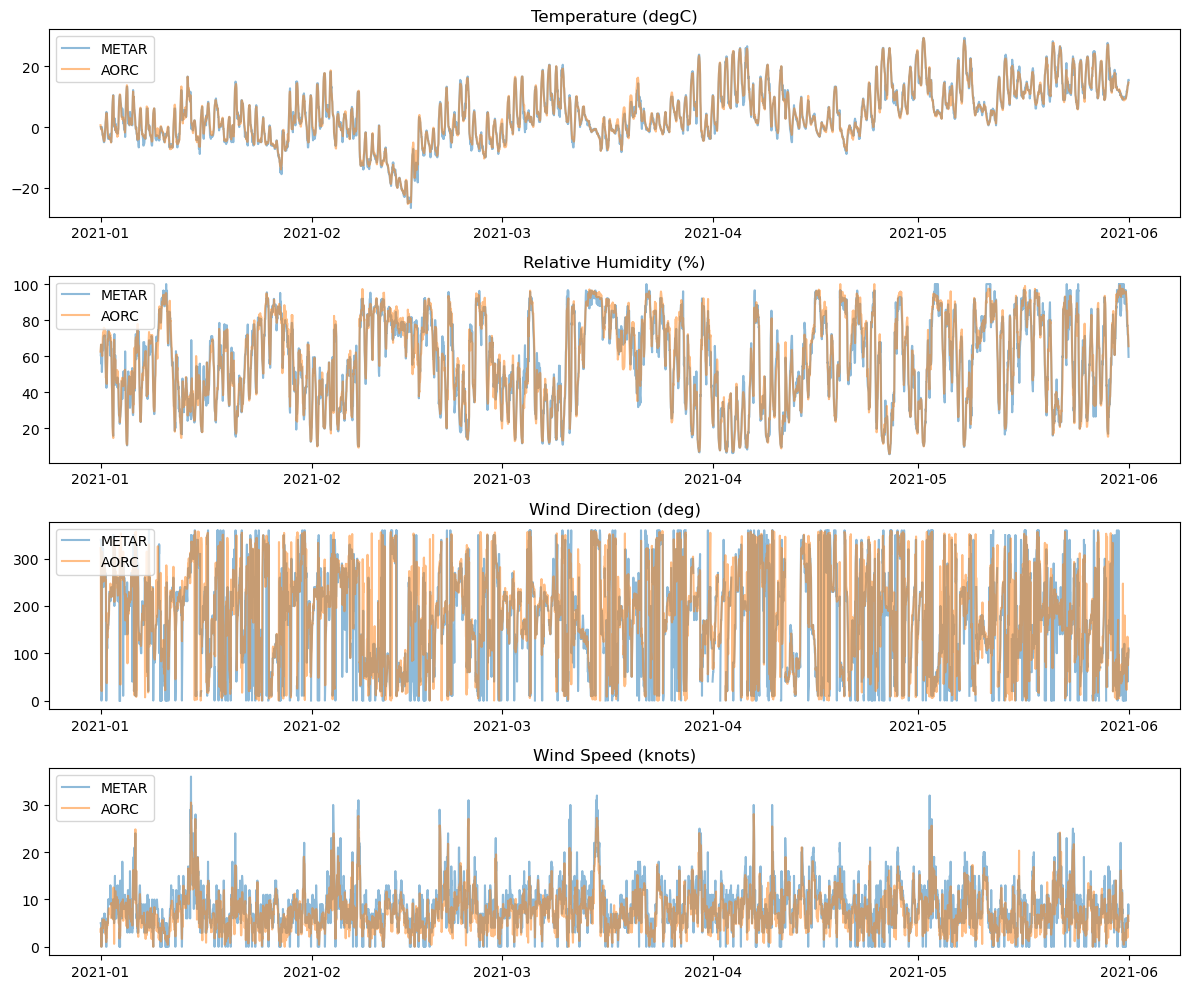

In [48]:
fig, axes = plt.subplots(len(target_vars), 1, figsize=(3 * len(target_vars), 10)) 

for i, v in enumerate(target_vars): 
    axes[i].set_title(col_refs[v])
    axes[i].plot(gdf_metar['valid'], gdf_metar[v], label='METAR', alpha=0.5) 
    axes[i].plot(gdf_aorc['time'], gdf_aorc[v], label='AORC', alpha=0.5)

    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()